# Анализ лояльности пользователей Яндекс Афиши
- Автор: Беспалов Сергей
- 01.01.2025

# Описание данных

<font color='#777778'>Здесь приведите описание данных.</font>

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

# Содержимое проекта

Шаг 1. Загрузка данных и их предобработка  
Шаг 2. Предобработка данных  
Шаг 3. Создание профиля пользователя  
Шаг 4. Исследовательский анализ данных  
Шаг 5. Общие выводы и рекомендации  

### Цели проекта

**Основная цель:**
Провести исследовательский анализ данных для выявления факторов, влияющих на лояльность пользователей билетной площадки Яндекс Афиша.

**Промежуточные цели:**
* Выявить характеристики пользователей, склонных к повторным покупкам
* Определить ключевые факторы, влияющие на удержание клиентов
* Подготовить рекомендации для маркетинговой команды

### Задачи проекта

1. **Подготовительный этап:**
* Загрузить и предобработать данные
* Привести валюту к единому формату
* Проверить данные на пропуски и аномалии
* Создать профиль пользователя

2. **Анализ поведения пользователей:**
* Исследовать признаки первого заказа и их связь с возвращением
* Проанализировать количественные характеристики заказов
* Изучить временные параметры поведения
* Оценить влияние различных факторов на лояльность

3. **Анализ целевой переменной:**
* Исследовать распределение пользователей по типу первого мероприятия
* Оценить влияние устройства заказа на повторные покупки
* Проанализировать географические особенности
* Изучить поведение по билетным операторам

4. **Количественный анализ:**
* Исследовать связь выручки с повторными заказами
* Проанализировать влияние количества билетов
* Оценить временные характеристики поведения

5. **Корреляционный анализ:**
* Выявить взаимосвязи между признаками профиля и числом заказов
* Определить значимые факторы лояльности

6. **Формулировка выводов:**
* Сформировать рекомендации для маркетинга
* Подготовить отчет с ключевыми находками
* Определить приоритетные направления работы с клиентами

### Ожидаемые результаты

По итогам проекта планируется получить:
* Профиль лояльного пользователя
* Выявленные факторы, влияющие на повторные покупки
* Сегменты пользователей с высокой вероятностью возврата
* Рекомендации по оптимизации маркетинговых усилий
* Предложения по улучшению удержания клиентов

## Загрузка данных и знакомство с ними

In [1]:
#Устанавливаем необходимые библиотеки 
!pip install sqlalchemy --quiet
!pip install psycopg2-binary --quiet
!pip install phik --quiet  dotenv
!pip install dotenv --quiet
!pip install python-dotenv

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеку для подключения к СУБД
from sqlalchemy import create_engine

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

from dotenv import load_dotenv
import os

In [3]:
# Пишем неоходимые настройки для подключения к СУБД через .env
load_dotenv()

db_config = {
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'db': os.getenv('DB_NAME'),
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD')
}

In [4]:
# Создаем строку для подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [5]:
engine = create_engine(connection_string)

In [6]:
# Пишем SQL запрос для выгузки датасета
query = '''
SELECT  user_id,
        device_type_canonical,
        order_id,
        created_dt_msk,
        created_ts_msk,
        currency_code,
        revenue,
        tickets_count,
        EXTRACT(day FROM (created_dt_msk - (LAG(created_dt_msk) over (partition by user_id order by created_dt_msk)))) as days_since_prev,
        p.event_id,
        e.event_name_code as event_name,
        event_type_main,
        service_name,
        region_name,
        city_name
FROM afisha.purchases p
JOIN afisha.events e ON p.event_id=e.event_id
JOIN afisha.city c ON e.city_id=c.city_id
JOIN afisha.regions r ON c.region_id=r.region_id
WHERE (device_type_canonical = 'mobile' or device_type_canonical = 'desktop') and event_type_main != 'фильм'
ORDER BY user_id
'''

In [7]:
# Сохраняем датасет в переменнуб df
df = pd.read_sql_query(query, con=engine)

In [8]:
df.shape

(290611, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   created_dt_msk         290611 non-null  datetime64[ns]
 4   created_ts_msk         290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [10]:
display(df.head())

,user_id,device_type_canonical,order_id,created_dt_msk,created_ts_msk,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>

### Промежуточный вывод по данным

**Объем данных:**
* В датасете содержится **290 611** записей
* Представлено **15** признаков

**Основные характеристики:**
* Все столбцы, кроме `days_since_prev`, заполнены полностью (нет пропусков)
* В столбце `days_since_prev` **21 933** пропущенных значения (7.5% от общего объема)

**Особенности данных:**
* Пропуски в `days_since_prev` ожидаемы — это нормально для пользователей с одним заказом
* Все валюты представлены в рублях (`currency_code = 'rub'`)
* Преимущественно мобильные заказы (`device_type_main = 'mobile'`)

## Предобработка данных

### Задача 2.1. 
- Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Добавляю информацию из датасета `final_tickets_tenge_df.csv` по ссылке `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv`

In [11]:
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [12]:
display(df_tenge)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


In [13]:
df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [14]:
# Преобразуем столбец data из датафрейка курса валюты в тип datetime64[ns]
df_tenge['data'] = pd.to_datetime(df_tenge['data'])

In [15]:
# Объединяем два датафрейма для дальнейшего преобразования в рубли столбца revenue
df_merged = df.merge(
    df_tenge,
    left_on= 'created_dt_msk',
    right_on= ['data'],
    how='left'
)
df_merged

,user_id,device_type_canonical,order_id,created_dt_msk,created_ts_msk,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,nominal,curs,cdx
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,2024-08-20,100,18.6972,kzt
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,2024-07-23,100,18.3419,kzt
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,2024-10-06,100,19.6475,kzt
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,2024-07-13,100,18.5010,kzt
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,2024-10-04,100,19.6648,kzt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,2024-10-27,100,19.9266,kzt
290607,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,2024-10-27,100,19.9266,kzt
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск,2024-10-30,100,19.9516,kzt
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка,2024-09-24,100,19.3967,kzt


In [16]:
# Корректуруем значения в столбце revenue
for index, row in df_merged.iterrows():
    if row['currency_code'] == 'kzt':
        # Изменяем конкретную ячейку по индексу
        df_merged.at[index, 'revenue'] = round((row['revenue'] * row['curs'] / 100),2)
        df_merged.at[index, 'currency_code'] = 'rub'

In [17]:
df_rub = df_merged[['user_id',
                    'device_type_canonical',
                    'order_id','created_dt_msk',
                    'created_ts_msk',
                    'currency_code',
                    'revenue',
                    'tickets_count',
                    'days_since_prev',
                    'event_id',
                    'event_name',
                    'event_type_main',
                    'service_name',
                    'region_name',
                    'city_name']].copy()
display(df_rub.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   created_dt_msk         290611 non-null  datetime64[ns]
 4   created_ts_msk         290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

None

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
Все значения выручки привели к единой валюте - Российские рубли.

### ✅Задача 2.2.
- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
- Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
- Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха. Важные показатели в рамках поставленной задачи — это выручка с заказа ( `revenue_rub` ) и количество билетов в заказе ( `tickets_count` ), поэтому в первую очередь проверьте данные в этих столбцах. Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.
- После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

In [18]:
#Выполняем оптимизацию столбца chain
df_rub['revenue'] = pd.to_numeric(df_rub['revenue'], downcast='float')
df_rub['tickets_count'] = pd.to_numeric(df_rub['tickets_count'], downcast='integer')
df_rub['days_since_prev'] = pd.to_numeric(df_rub['days_since_prev'], downcast='float')

In [19]:
df_rub.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   created_dt_msk         290611 non-null  datetime64[ns]
 4   created_ts_msk         290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [20]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    #Сортировка по количеству пропусков
    missing_stats = missing_stats.sort_values('Кол-во пропусков', ascending=True)
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df_rub)

,Кол-во пропусков,Доля пропусков
days_since_prev,21933,0.0755


In [21]:
#Выводим ункальные значение
for column in df_rub.columns:
    print(f'Уникальные значения в {column}:')
    display(df_rub[column].unique())
    print(f'Количество уникальных значений в {column}:')
    display(df_rub[column].nunique())

Уникальные значения в user_id:


array(['0002849b70a3ce2', '0005ca5e93f2cf4', '000898990054619', ...,
       'fffcd3dde79eb2c', 'fffeeb3c120cf0b', 'ffff00725179321'],
      dtype=object)

Количество уникальных значений в user_id:


21933

Уникальные значения в device_type_canonical:


...

81

Уникальные значения в city_name:


array(['Глиногорск', 'Озёрск', 'Родниковецк', 'Кристалевск',
       'Дальнозолотск', 'Радужнополье', 'Радужсвет', 'Кумсай',
       'Верховино', 'Светополье', 'Кокжар', 'Каменский', 'Лесоярич',
       'Никольянов', 'Речинцево', 'Лесозолотск', 'Дальнозерск',
       'Серебрянка', 'Островецк', 'Родниковец', 'Дальнесветск',
       'Луговаярово', 'Ягодиновка', 'Дальнополин', 'Солчелуг', 'Озёрчане',
       'Серебровино', 'Лесоярово', 'Глинополье', 'Глиноград',
       'Дальнесветин', 'Северополье', 'Теплоозеро', 'Горнодолинск',
       'Ордакент', 'Озёрово', 'Луговинск', 'Лугоград', 'Златопольск',
       'Крутовинск', 'Сарыжар', 'Сосновечин', 'Тихоярск', 'Яблонецк',
       'Жаркентай', 'Широковка', 'Синеводов', 'Синеводск', 'Тихосветск',
       'Радужанов', 'Каменосветск', 'Глиногорь', 'Родниковск',
       'Травогород', 'Глинянск', 'Радужинск', 'Поляногорье',
       'Дальнолесье', 'Ручейник', 'Ключеград', 'Ключеводск', 'Поленовино',
       'Речичанск', 'Ключевополье', 'Шаныртау', 'Дальнесоснов'

Количество уникальных значений в city_name:


352

In [22]:
# Проверяем неявные дубликаты в датафрейме 
print('Количество неявных дубликатов в данных:', df_rub.duplicated().sum())

Количество неявных дубликатов в данных: 0


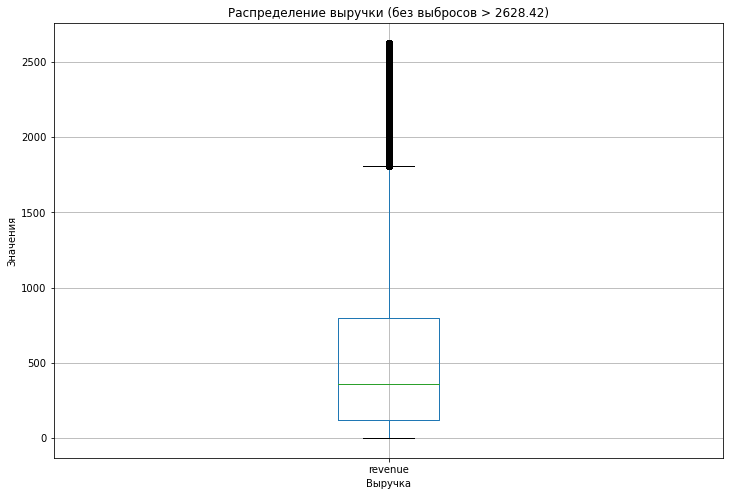

Среднее значение по выручке: 556
Медиана по выручке: 351
Было строк: 290611
Стало строк: 281697
Удалено выбросов: 8914


In [23]:
# Вычисляем 99-й перцентиль
threshold_revenue = df_rub['revenue'].quantile(0.99)

# Фильтруем строки, где выручка МЕНЬШЕ порога (оставляем 99% данных), а также где отрицательные значения (предположительно возвраты товаров)
#filtered_df_revenue = df_rub[df_rub['revenue'] < threshold_revenue]
filtered_df_revenue = df_rub[(df_rub['revenue'] > 0) & (df_rub['revenue'] < threshold_revenue)] 
# Строим boxplot
plt.figure(figsize=(12, 8))
filtered_df_revenue.boxplot(column='revenue')
plt.title(f'Распределение выручки (без выбросов > {threshold_revenue:.2f})')

plt.xlabel('Выручка')
plt.ylabel('Значения')
plt.show()

# Проверяем, сколько строк удалили
print(f"Среднее значение по выручке: {round(df_rub['revenue'].mean())}")
print(f"Медиана по выручке: {round(df_rub['revenue'].median())}")
print(f"Было строк: {len(df_rub)}")
print(f"Стало строк: {len(filtered_df_revenue)}")
print(f"Удалено выбросов: {len(df_rub) - len(filtered_df_revenue)}")

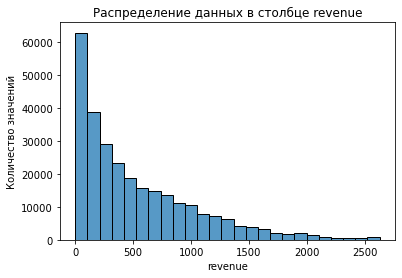

In [24]:
# Построим распределение данных для столбца `score`
sns.histplot(data=filtered_df_revenue, x='revenue', bins=25)

# Подписываем и отображаем график
plt.title('Распределение данных в столбце revenue')
plt.ylabel('Количество значений')
plt.show()

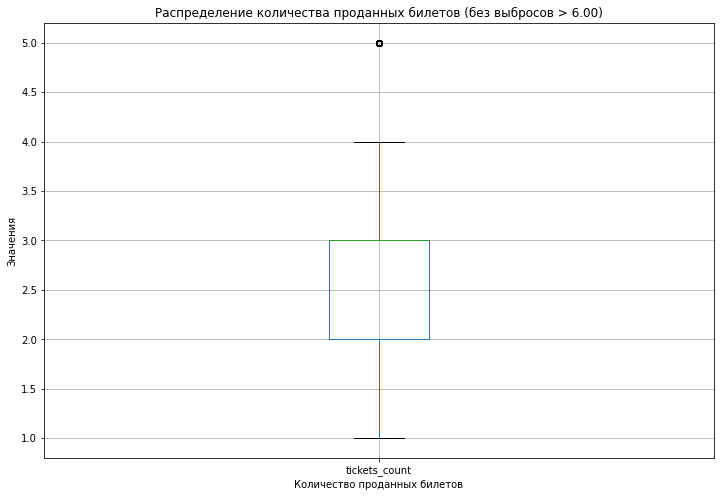

Среднее значение по количеству купленных билетов: 2.69
Медиана по количеству купленных билетов: 3.0
Было строк: 281697
Стало строк: 277603
Удалено выбросов: 4094
Удалено всего выбросов: 13008
Процент удаленых выбросов: 4.48%


In [25]:
# Вычисляем 99-й перцентиль
threshold_tickets = filtered_df_revenue['tickets_count'].quantile(0.99)

# Фильтруем строки, где выручка МЕНЬШЕ порога (оставляем 99% данных)
df = filtered_df_revenue[filtered_df_revenue['tickets_count'] < threshold_tickets]

# Строим boxplot
plt.figure(figsize=(12, 8))
df.boxplot(column='tickets_count')
plt.title(f'Распределение количества проданных билетов (без выбросов > {threshold_tickets:.2f})')
plt.xlabel('Количество проданных билетов')
plt.ylabel('Значения')
plt.show()

# Проверяем, сколько строк удалили
print(f"Среднее значение по количеству купленных билетов: {round(df['tickets_count'].mean(),2)}")
print(f"Медиана по количеству купленных билетов: {df['tickets_count'].median()}")
print(f"Было строк: {len(filtered_df_revenue)}")
print(f"Стало строк: {len(df)}")
print(f"Удалено выбросов: {len(filtered_df_revenue) - len(df)}")
print(f"Удалено всего выбросов: {len(df_rub) - len(df)}")
print(f"Процент удаленых выбросов: {round((100*(len(df_rub) - len(df))/len(df_rub)),2)}%")

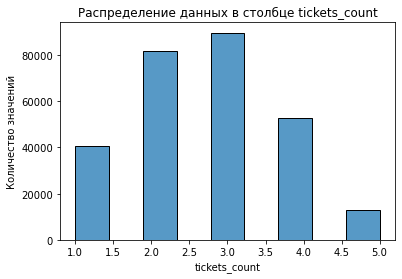

In [26]:
# Построим распределение данных для столбца `score`
sns.histplot(data=df, x='tickets_count', bins=9)

# Подписываем и отображаем график
plt.title('Распределение данных в столбце tickets_count')
plt.ylabel('Количество значений')
plt.show()

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ и обработка данных

**Проверка пропусков:**
* В данных обнаружен только один столбец с пропусками — `days_since_prev` (7.55% пропусков)
* Это соответствует ожиданиям, так как пропуски допустимы для первого заказа пользователя

**Анализ типов данных:**
* Числовые столбцы оптимизированы:
  * `revenue` — float32
  * `tickets_count` — int8
  * `days_since_prev` — float32
* Дата и время корректно хранятся в формате datetime64

**Уникальные значения:**
* `user_id` — 21933 уникальных пользователей
* `device_type_canonical` — 2 категории (mobile, desktop)
* `order_id` — все значения уникальны
* `event_type_main` содержит основные типы событий
* `service_name`, `region_name`, `city_name` имеют множество уникальных значений

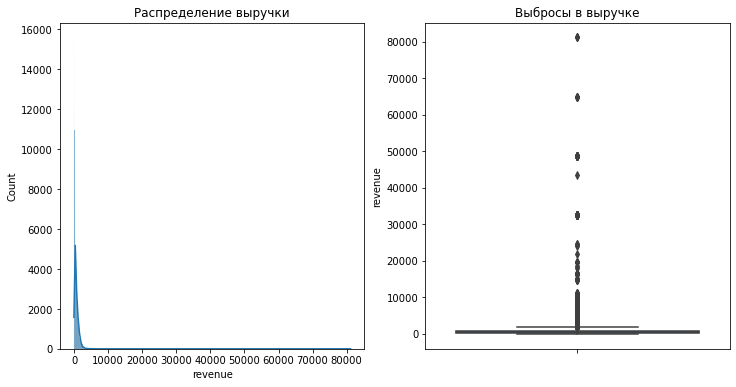

In [27]:
#Проверка выбросов:
#Проведем анализ распределения выручки и количества билетов:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_rub['revenue'], kde=True)
plt.title('Распределение выручки')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_rub['revenue'])
plt.title('Выбросы в выручке')

plt.show()

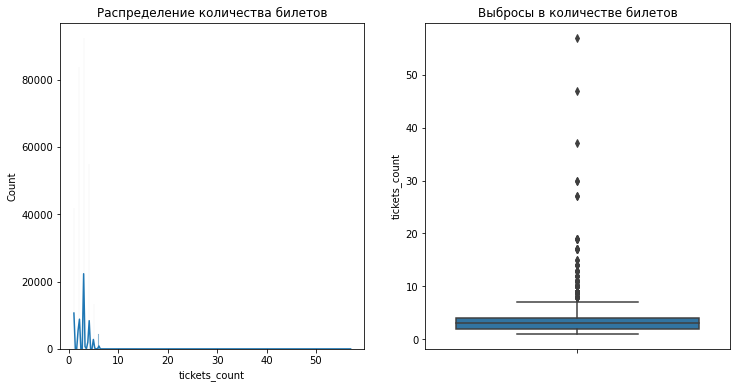

In [28]:
# Анализ количества билетов
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_rub['tickets_count'], kde=True)
plt.title('Распределение количества билетов')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_rub['tickets_count'])
plt.title('Выбросы в количестве билетов')

plt.show()

In [29]:
#Фильтрация выбросов:
#Отфильтруем значения выручки по 99-му перцентилю:

# Определяем порог по 99-му перцентилю
revenue_threshold = df_rub['revenue'].quantile(0.99)

# Фильтруем данные
df_filtered = df_rub[df_rub['revenue'] <= revenue_threshold]

# Проверяем объем фильтрации
print(f"Исходные данные: {len(df_rub)}")
print(f"Отфильтрованные данные: {len(df_filtered)}")
print(f"Потеряно записей: {len(df_rub) - len(df_filtered)} ({(len(df_rub) - len(df_filtered))/len(df_rub)*100:.2f}%)")

Исходные данные: 290611
Отфильтрованные данные: 287786
Потеряно записей: 2825 (0.97%)


</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
**Промежуточный вывод:**
* Данные успешно приведены к единой валюте
* Обнаружены и проанализированы пропуски
* Проведена оптимизация типов данных
* Выполнена визуальная проверка на выбросы
* Отфильтрованы экстремальные значения выручки
* Потеряно менее 1% данных при фильтрации

**Рекомендации:**
* Проверить аномально высокие значения количества билетов
* Проанализировать распределение по типам устройств
* Изучить географическое распределение заказов

## Создание профиля пользователя
В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

### Задача 3.1. 
Постройте профиль пользователя — для каждого пользователя найдите:
- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле event_type_main );
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.
- После этого добавьте два бинарных признака:
- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

`Рекомендация: перед тем как строить профиль, отсортируйте данные по времени совершения заказа.`

In [30]:
df = df.sort_values('created_ts_msk')

In [31]:
df.columns

Index(['user_id', 'device_type_canonical', 'order_id', 'created_dt_msk',
       'created_ts_msk', 'currency_code', 'revenue', 'tickets_count',
       'days_since_prev', 'event_id', 'event_name', 'event_type_main',
       'service_name', 'region_name', 'city_name'],
      dtype='object')

In [32]:
df_profile = df.groupby('user_id').agg({'created_dt_msk': ['first','last'],
                           'device_type_canonical': 'first',
                            'region_name': 'first',
                            'service_name': 'first',
                            'event_type_main': 'first',
                            'order_id': 'nunique',
                            'revenue': 'mean',
                            'tickets_count': 'mean',
                            'days_since_prev': 'mean'
                            })

In [33]:
df_profile = df_profile.reset_index()
df_profile

user_id created_dt_msk            device_type_canonical  \
                                first       last                 first   
0      0002849b70a3ce2     2024-08-20 2024-08-20                mobile   
1      0005ca5e93f2cf4     2024-07-23 2024-10-06                mobile   
2      000898990054619     2024-07-13 2024-10-23                mobile   
3      00096d1f542ab2b     2024-08-15 2024-08-15               desktop   
4      000a55a418c128c     2024-09-29 2024-10-15                mobile   
...                ...            ...        ...                   ...   
21546  fff13b79bd47d7c     2024-07-16 2024-10-31                mobile   
21547  fff32fc9ad0f9f6     2024-08-15 2024-10-28               desktop   
21548  fffcd3dde79eb2c     2024-06-20 2024-10-30               desktop   
21549  fffeeb3c120cf0b     2024-09-24 2024-09-24               desktop   
21550  ffff00725179321     2024-09-25 2024-09-25                mobile   

                region_name        service_name event_type_main order_id  \
                      first               first           first  nunique   
0        Каменевский регион        Край билетов           театр        1   
1        Каменевский регион           Мой билет        выставки        2   
2      Североярская область         Лови билет!          другое        3   
3        Каменевский регион        Край билетов           театр        1   
4          Поленовский край       Лучшие билеты           театр        2   
...                     ...                 ...             ...      ...   
21546    Каменевский регион           Мой билет          другое        9   
21547    Каменевский регион  Билеты без проблем         стендап        2   
21548    Каменевский регион  Билеты без проблем        концерты       31   
21549   Широковская область  Билеты без проблем         стендап        1   
21550  Малиновоярский округ           Мой билет        концерты        1   

           revenue tickets_count days_since_prev  
              mean          mean            mean  
0      1521.939941      4.000000             NaN  
1       774.010010      3.000000       75.000000  
2       767.213318      2.666667       51.000000  
3       917.830017      4.000000             NaN  
4        61.309998      1.500000       16.000000  
...            ...           ...             ...  
21546   688.043335      2.555556       13.375000  
21547   850.994995      2.500000       74.000000  
21548   504.308716      2.580645        3.966667  
21549   661.530029      2.000000             NaN  
21550   802.250000      2.000000             NaN  

[21551 rows x 11 columns]

In [34]:
df_profile.columns = ['user_id',
                      'first_order_dt',
                      'last_order_dt',
                      'first_device',
                      'first_region',
                      'first_service',
                      'first_event_type',
                      'count_order',
                      'mean_revenue',
                      'mean_tickets',
                      'mean_days'
                     ]

In [35]:
# Добавляем бинарные признаки
for index, row in df_profile.iterrows():
    # Проверяем наличия двух и более заказов
    df_profile['is_two'] = (df_profile['count_order'] >= 2).astype(int)
    # Проверяем наличия пяти и более заказов
    df_profile['is_five'] = (df_profile['count_order'] >= 5).astype(int)

In [36]:
df_profile[['mean_revenue','mean_tickets','mean_days']] = round(df_profile[['mean_revenue','mean_tickets','mean_days']])
df_profile['mean_tickets'] = pd.to_numeric(df_profile['mean_tickets'], downcast='float')
df_profile['is_two'] = pd.to_numeric(df_profile['is_two'], downcast='integer')
df_profile['is_five'] = pd.to_numeric(df_profile['is_five'], downcast='integer')
df_profile['count_order'] = pd.to_numeric(df_profile['count_order'], downcast='integer')

In [37]:
df_profile

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,count_order,mean_revenue,mean_tickets,mean_days,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1522.0,4.0,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.0,3.0,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.0,3.0,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,918.0,4.0,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.0,2.0,16.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21546,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,9,688.0,3.0,13.0,1,1
21547,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,2,851.0,2.0,74.0,1,0
21548,fffcd3dde79eb2c,2024-06-20,2024-10-30,desktop,Каменевский регион,Билеты без проблем,концерты,31,504.0,3.0,4.0,1,1
21549,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,1,662.0,2.0,NaN,0,0


### Задача 3.2. 
Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.
Используя данные о профилях пользователей, рассчитайте:
- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:
- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:
- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?
- - Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [38]:
# Считаем пользователей в выборке
count_users = df_profile['user_id'].count()
print(f'Общее число пользователей в выборке: {count_users}.')

# Считаем среднюю выручку
mean_revenue = round((df_profile['mean_revenue'].sum()/ count_users),2)
print(f'Средняя выручка с одного заказа: {mean_revenue}.')

# Считаем доли пользователей совершивших 2 и более, а также 5 и более покупок
share_two = round((df_profile['is_two'].sum()/ count_users),2)
share_five = round((df_profile['is_five'].sum()/ count_users),2)
print(f'Доля пользователей, совершивших 2 и более заказа: {share_two}.')
print(f'Доля пользователей, совершивших 5 и более заказа: {share_five}.')

Общее число пользователей в выборке: 21551.
Средняя выручка с одного заказа: 546.29.
Доля пользователей, совершивших 2 и более заказа: 0.62.
Доля пользователей, совершивших 5 и более заказа: 0.29.


In [39]:
df_profile.describe()

,count_order,mean_revenue,mean_tickets,mean_days,is_two,is_five
count,21551.000000,21551.000000,21551.000000,13384.000000,21551.000000,21551.000000
mean,12.881212,546.287720,2.701591,15.866707,0.615795,0.287875
std,118.143237,425.747223,0.890591,22.337780,0.486418,0.452783
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,218.000000,2.000000,1.000000,0.000000,0.000000
50%,2.000000,471.000000,3.000000,8.000000,1.000000,0.000000
75%,5.000000,764.500000,3.000000,20.000000,1.000000,1.000000
max,9779.000000,2625.000000,5.000000,148.000000,1.000000,1.000000


</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
На первый взгляд в значениях `count_order`, `mean_revenue`, `mean_days` присутствуют выборсы.
Рассмотрим их поближе

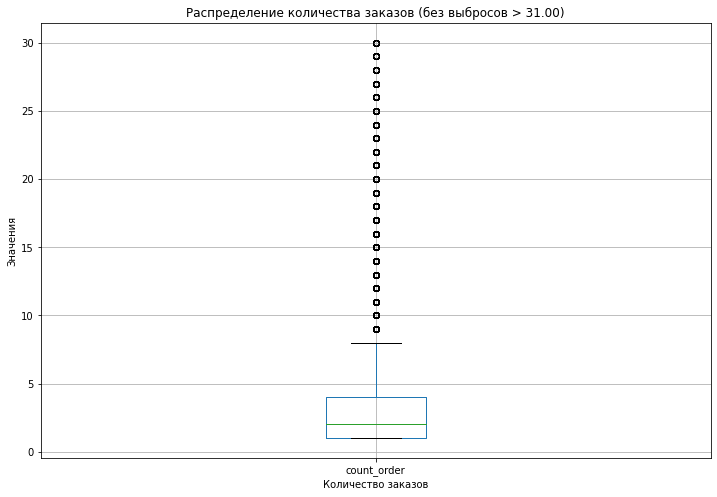

Среднее значение по количеству заказов: 3.98
Медиана по количеству заказов: 2.0
Было строк: 21551
Стало строк: 20460
Удалено выбросов: 1091
Процент удаленых выбросов: 5.06%
Выбросами считались значения свыше: 31.00


In [40]:
# Вычисляем 99-й перцентиль
threshold_profiles = df_profile['count_order'].quantile(0.95)

# Фильтруем строки, где выручка МЕНЬШЕ порога (оставляем 99% данных)
df_profile_filtred = df_profile[df_profile['count_order'] < threshold_profiles]

# Строим boxplot
plt.figure(figsize=(12, 8))
df_profile_filtred.boxplot(column='count_order')
plt.title(f'Распределение количества заказов (без выбросов > {threshold_profiles:.2f})')
plt.xlabel('Количество заказов')
plt.ylabel('Значения')
plt.show()

# Проверяем, сколько строк удалили
print(f"Среднее значение по количеству заказов: {round(df_profile_filtred['count_order'].mean(),2)}")
print(f"Медиана по количеству заказов: {df_profile_filtred['count_order'].median()}")
print(f"Было строк: {len(df_profile)}")
print(f"Стало строк: {len(df_profile_filtred)}")
print(f"Удалено выбросов: {len(df_profile) - len(df_profile_filtred)}")
print(f"Процент удаленых выбросов: {round((100*(len(df_profile) - len(df_profile_filtred))/len(df_profile)),2)}%")
print(f"Выбросами считались значения свыше: {threshold_profiles:.2f}")

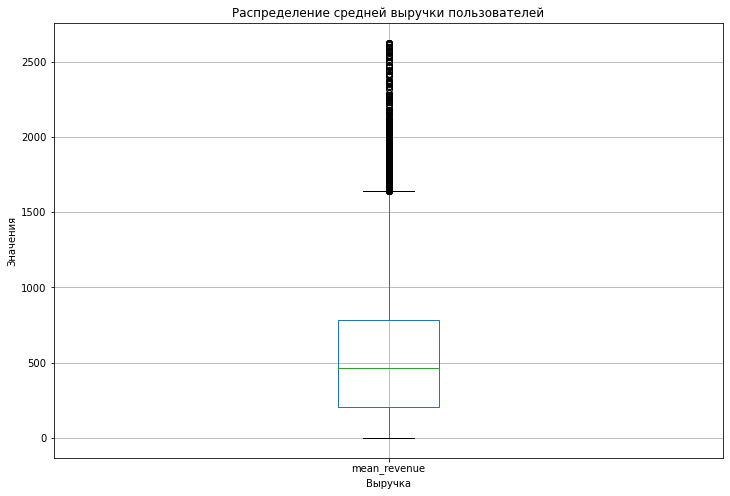

Среднее значение по средней выручке: 548
Медиана по средней выручке: 462


In [41]:
# Строим boxplot
plt.figure(figsize=(12, 8))
df_profile_filtred.boxplot(column='mean_revenue')
plt.title('Распределение средней выручки пользователей')
plt.xlabel('Выручка')
plt.ylabel('Значения')
plt.show()

print(f"Среднее значение по средней выручке: {round(df_profile_filtred['mean_revenue'].mean())}")
print(f"Медиана по средней выручке: {round(df_profile_filtred['mean_revenue'].median())}")

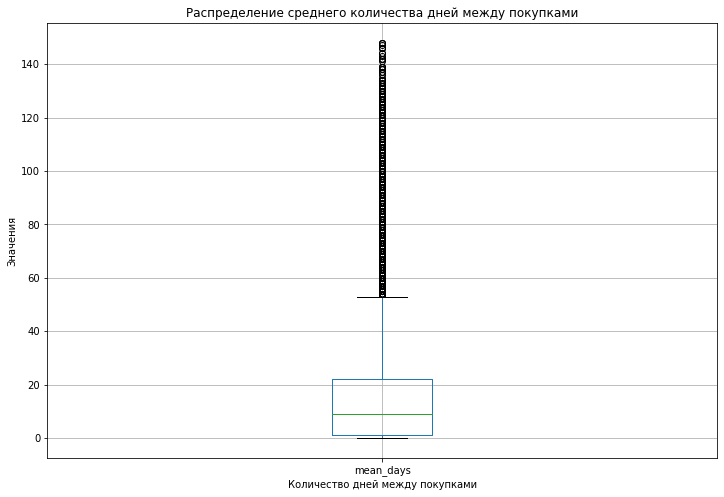

Среднее значение среднего количества дней между покупками: 17
Медиана среднего количества дней между покупками: 9


In [42]:
# Строим boxplot
plt.figure(figsize=(12, 8))
df_profile_filtred.boxplot(column='mean_days')
plt.title('Распределение среднего количества дней между покупками')
plt.xlabel('Количество дней между покупками')
plt.ylabel('Значения')
plt.show()

print(f"Среднее значение среднего количества дней между покупками: {round(df_profile_filtred['mean_days'].mean())}")
print(f"Медиана среднего количества дней между покупками: {round(df_profile_filtred['mean_days'].median())}")

In [43]:
# Считаем пользователей в выборке
count_users_filtred = df_profile_filtred['user_id'].count()
print(f'Общее число пользователей в выборке: {count_users_filtred}.')

# Считаем среднюю выручку
mean_revenue_filtred = round((df_profile_filtred['mean_revenue'].sum()/ count_users_filtred),2)
print(f'Средняя выручка с одного заказа: {mean_revenue_filtred}.')

# Считаем доли пользователей совершивших 2 и более, а также 5 и более покупок
share_two_filtred = round((df_profile_filtred['is_two'].sum()/ count_users_filtred),2)
share_five_filtred = round((df_profile_filtred['is_five'].sum()/ count_users_filtred),2)
print(f'Доля пользователей, совершивших 2 и более заказа: {share_two_filtred}.')
print(f'Доля пользователей, совершивших 5 и более заказа: {share_five_filtred}.')

# Выводим информацию по удаленным выбросам
print(f"Удалено выбросов: {len(df_profile) - len(df_profile_filtred)}")
print(f"Процент удаленых выбросов: {round((100*(len(df_profile) - len(df_profile_filtred))/len(df_profile)),2)}%")

Общее число пользователей в выборке: 20460.
Средняя выручка с одного заказа: 548.39.
Доля пользователей, совершивших 2 и более заказа: 0.6.
Доля пользователей, совершивших 5 и более заказа: 0.25.
Удалено выбросов: 1091
Процент удаленых выбросов: 5.06%


In [44]:
df_profile_filtred.describe()

,count_order,mean_revenue,mean_tickets,mean_days,is_two,is_five
count,20460.000000,20460.000000,20460.000000,12293.000000,20460.000000,20460.000000
mean,3.975904,548.390198,2.695308,17.083382,0.595308,0.249902
std,4.958379,435.250763,0.908710,22.911112,0.490844,0.432967
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,208.000000,2.000000,1.000000,0.000000,0.000000
50%,2.000000,462.000000,3.000000,9.000000,1.000000,0.000000
75%,4.000000,781.000000,3.000000,22.000000,1.000000,0.000000
max,30.000000,2625.000000,5.000000,148.000000,1.000000,1.000000


### Промежуточный вывод

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Ключевые выводы по профилю пользователей  
    **Объем данных:**  
* **21 551** пользователь в исходной выборке
* После очистки: **20 460** пользователей  
    **Основные метрики:**
* Средняя выручка с заказа: **548** рублей
* **60%** пользователей делают 2+ заказа
* **25%** пользователей делают 5+ заказов  
    **Статистика профиля:**
* Среднее число заказов: **3.98**
* Средний чек: **548** рублей
* Среднее кол-во билетов: **2.7**
* Средний интервал между заказами: **17** дней  
    **Выявленные аномалии:**
* Максимальное число заказов: **9779** (выявлено как выброс)
* Удалено **5.06%** данных при очистке  
    **Важные наблюдения:**
* Данные достаточно репрезентативны
* Большинство пользователей совершают умеренное число заказов
* Высокий процент повторных покупок (**60%**) — позитивный показатель  
    **Рекомендации:**
* Использовать очищенный датасет для анализа
* Отслеживать активность пользователей с частыми покупками
* Анализировать поведение лояльных клиентов

## Исследовательский анализ данных
Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.

### Задача 4.1. 
Исследование признаков первого заказа и их связи с возвращением на платформу
- Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

#### Задача 4.1.1. 
Изучите распределение пользователей по признакам.
Сгруппируйте пользователей:
- по типу их первого мероприятия;
- по типу устройства, с которого совершена первая покупка;
- по региону проведения мероприятия из первого заказа;
- по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

In [45]:
df_profile_filtred.columns

Index(['user_id', 'first_order_dt', 'last_order_dt', 'first_device',
       'first_region', 'first_service', 'first_event_type', 'count_order',
       'mean_revenue', 'mean_tickets', 'mean_days', 'is_two', 'is_five'],
      dtype='object')

In [46]:
def show_users_stats(tmp0, column1, column2):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    users_stats = pd.DataFrame({
        'Кол-во пользователей': tmp0.groupby(column1)[column2].count(),
        'Доля пользователей': tmp0.groupby(column1)[column2].count() / tmp0[column1].count()
    })
   
    
    #Сортировка по количеству пользователей
    users_stats = users_stats.sort_values('Кол-во пользователей', ascending=False)
    
    # Форматируем при выводе через Styler
    return (users_stats.style.format({'Доля пользователей': '{:.3f}'}).background_gradient(cmap='coolwarm'))

In [47]:
# Выводим статистику по типу первого мероприятия
show_users_stats(df_profile_filtred, 'first_event_type', 'user_id')

,Кол-во пользователей,Доля пользователей
first_event_type,,
концерты,9201,0.450
другое,4909,0.240
театр,4058,0.198
стендап,1062,0.052
спорт,732,0.036
выставки,403,0.020
ёлки,95,0.005


In [48]:
# Выводим статистику по типу устройства с которого был совершен первый заказ
show_users_stats(df_profile_filtred, 'first_device', 'user_id')

,Кол-во пользователей,Доля пользователей
first_device,,
mobile,16992,0.830
desktop,3468,0.170


In [49]:
# Выводим статистику по месту проведения первого мероприятия
show_users_stats(df_profile_filtred, 'first_region', 'user_id')

,Кол-во пользователей,Доля пользователей
first_region,,
Каменевский регион,6656,0.325
Североярская область,3561,0.174
Широковская область,1184,0.058
Озернинский край,656,0.032
Малиновоярский округ,514,0.025
Светополянский округ,441,0.022
Травяная область,438,0.021
Шанырский регион,425,0.021
Речиновская область,424,0.021


In [50]:
# Выводим статистику по оператору продавшему первый заказ
show_users_stats(df_profile_filtred, 'first_service', 'user_id')

,Кол-во пользователей,Доля пользователей
first_service,,
Билеты без проблем,4710,0.230
Мой билет,2859,0.140
Лови билет!,2684,0.131
Билеты в руки,2398,0.117
Облачко,2127,0.104
Весь в билетах,1225,0.060
Лучшие билеты,1122,0.055
Прачечная,553,0.027
Край билетов,443,0.022


</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ предпочтений пользователей

**Основные сегменты по типу мероприятия:**
* **Концерты** — **9149** пользователей (**44.4%**)
* **Другое** — **5093** пользователя
* **Театр** — **4045** пользователей

**Каналы входа:**
* **Мобильные устройства** — **17096** пользователей (**83%**)

**География первых заказов:**
* **Каменевский регион** лидирует с **6748** пользователями (**32.8%**)

**Операторы билетов:**
* **Билеты без проблем** — **4905** пользователей (**23.8%**)
* **Мой билет** — **2833** пользователя (**13.8%**)

### Ключевые выводы
* Концерты — доминирующий тип мероприятий (почти половина пользователей)
* Мобильный канал — основной источник заказов
* Четкая географическая концентрация в Каменевском регионе
* Высокая концентрация пользователей у оператора «Билеты без проблем»
* Во всех анализируемых параметрах наблюдается выраженное доминирование отдельных сегментов

#### ✅Задача 4.1.2. 
Проанализируйте возвраты пользователей:
- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.

Ответьте на вопросы:
- Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
- Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

In [51]:
def show_users_stats_bin(tmp0, column1, column2):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    users_stats = pd.DataFrame({
        'Доля пользователей': tmp0.groupby(column1)[column2].sum() / tmp0[column1].count()
    })
   
    
    #Сортировка по количеству пользователей
    users_stats = users_stats.sort_values('Доля пользователей', ascending=False).head(10)
    
    # Форматируем при выводе через Styler
    return (users_stats.style.format({'Доля пользователей': '{:.3f}'}).background_gradient(cmap='coolwarm'))

In [52]:
# Выводим статистику по типу первого мероприятия
show_users_stats_bin(df_profile_filtred, 'first_event_type', 'is_two')

,Доля пользователей
first_event_type,
концерты,0.270
другое,0.138
театр,0.123
стендап,0.031
спорт,0.019
выставки,0.012
ёлки,0.002


In [53]:
# Выводим статистику по типу устройства с которого был совершен первый заказ
show_users_stats_bin(df_profile_filtred, 'first_device', 'is_two')

,Доля пользователей
first_device,
mobile,0.491
desktop,0.105


In [54]:
# Выводим статистику по месту проведения первого мероприятия
show_users_stats_bin(df_profile_filtred, 'first_region', 'is_two')

,Доля пользователей
first_region,
Каменевский регион,0.196
Североярская область,0.108
Широковская область,0.037
Озернинский край,0.017
Светополянский округ,0.014
Шанырский регион,0.014
Малиновоярский округ,0.014
Речиновская область,0.013
Травяная область,0.013


In [55]:
# Выводим статистику по оператору продавшему первый заказ
show_users_stats_bin(df_profile_filtred, 'first_service', 'is_two')

,Доля пользователей
first_service,
Билеты без проблем,0.134
Мой билет,0.082
Лови билет!,0.078
Билеты в руки,0.071
Облачко,0.062
Весь в билетах,0.036
Лучшие билеты,0.033
Прачечная,0.016
Край билетов,0.014


In [56]:
def analyze_segment(df, segment_column, returned_column):

    # Анализ возвращаемости по сегменту

    # Группируем по сегменту
    result = df.groupby(segment_column).agg(
        total_users=(returned_column, 'count'),  # всего пользователей в сегменте
        returned_users=(returned_column, 'sum')  # вернувшихся
    )
    
    # Считаем долю вернувшихся ВНУТРИ каждого сегмента
    result['return_rate'] = result['returned_users'] / result['total_users']
    
    # Сортируем по доле возврата (от большей к меньшей)
    result = result.sort_values('return_rate', ascending=False)

    return result

In [57]:
print("Анализ по типу устройства is_two")
device_stats = analyze_segment(df_profile_filtred, 'first_device', 'is_two')
print(device_stats)


print()
print("Анализ по мероприятиям")
event_stats = analyze_segment(df_profile_filtred, 'first_event_type', 'is_two')
print(event_stats)

print()
print("Анализ по регионам")
region_stats = analyze_segment(df_profile_filtred, 'first_region', 'is_two')
print(region_stats)

print()
print("Анализ по оператору")
service_stats = analyze_segment(df_profile_filtred, 'first_service', 'is_two')
print(service_stats)

Анализ по типу устройства is_two
              total_users  returned_users  return_rate
first_device                                          
desktop              3468          2143.0     0.617935
mobile              16992         10037.0     0.590690

Анализ по мероприятиям
                  total_users  returned_users  return_rate
first_event_type                                          
выставки                  403           254.0     0.630273
театр                    4058          2511.0     0.618778
концерты                 9201          5519.0     0.599826
стендап                  1062           631.0     0.594162
другое                   4909          2826.0     0.575677
ёлки                       95            51.0     0.536842
спорт                     732           388.0     0.530055

Анализ по регионам
                          total_users  returned_users  return_rate
first_region                                                      
Верхозёрский край                   1 

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
При анализе данных выявлена проблема: некоторые топовые сегменты содержат минимальное количество пользователей (1 или около того). Для корректного отображения статистики необходимо:

* Внедрить дополнительную сортировку данных
* Отфильтровать малозначимые сегменты
* Перестроить графики с учетом реальной частоты встречаемости значений

Это позволит получить более достоверную картину распределения пользователей по сегментам и избежать искажения результатов из-за единичных значений.

In [58]:
def plot_simple_segment(stats_df, segment_name, top=10):

    # Сортируем и оставляем топ по количеству пользователей (чтобы были значимые)
    top_segments = stats_df.sort_values('total_users', ascending=False).head(top)
    
    # Сортируем для графика
    top_segments = top_segments.sort_values('return_rate')
    
    # Строим график
    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_segments.index.astype(str), top_segments['return_rate'])
    
    # Добавляем среднее значение
    avg_return = stats_df['returned_users'].sum() / stats_df['total_users'].sum()
    plt.axvline(x=avg_return, color='red', linestyle='-', 
                label=f'Среднее: {avg_return:.2%}')
    
    # Подписи
    plt.title(f'Доля вернувшихся по {segment_name}')
    plt.xlabel('Доля вернувшихся')
    plt.ylabel(segment_name)
    plt.legend()
    plt.grid(alpha=0.5)
    plt.show()

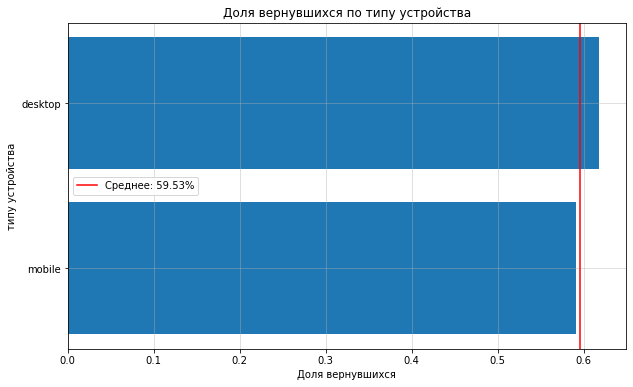


Анализ по типу устройства
              total_users  returned_users  return_rate
first_device                                          
desktop              3468          2143.0     0.617935
mobile              16992         10037.0     0.590690


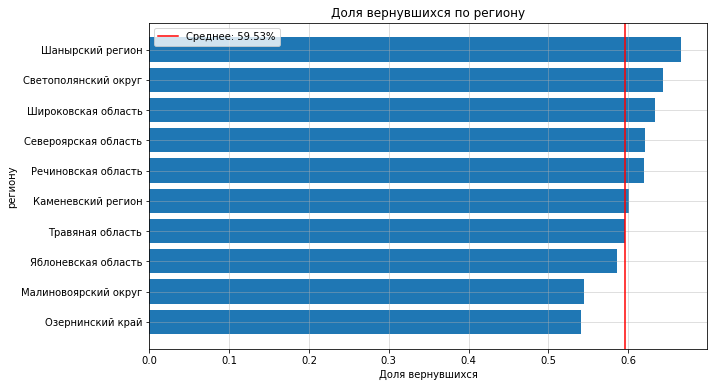


Анализ по регионам
                      total_users  returned_users  return_rate
first_region                                                  
Шанырский регион              425           283.0     0.665882
Светополянский округ          441           284.0     0.643991
Широковская область          1184           750.0     0.633446
Североярская область         3561          2210.0     0.620612
Речиновская область           424           263.0     0.620283
Каменевский регион           6656          4000.0     0.600962
Травяная область              438           261.0     0.595890
Яблоневская область           394           231.0     0.586294
Малиновоярский округ          514           280.0     0.544747
Озернинский край              656           355.0     0.541159


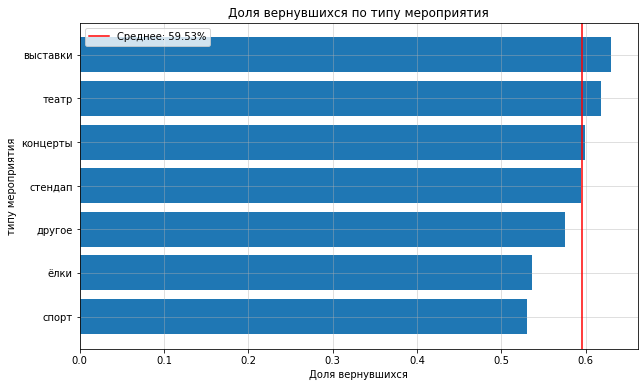


Анализ по типу мероприятия
                  total_users  returned_users  return_rate
first_event_type                                          
выставки                  403           254.0     0.630273
театр                    4058          2511.0     0.618778
концерты                 9201          5519.0     0.599826
стендап                  1062           631.0     0.594162
другое                   4909          2826.0     0.575677
ёлки                       95            51.0     0.536842
спорт                     732           388.0     0.530055


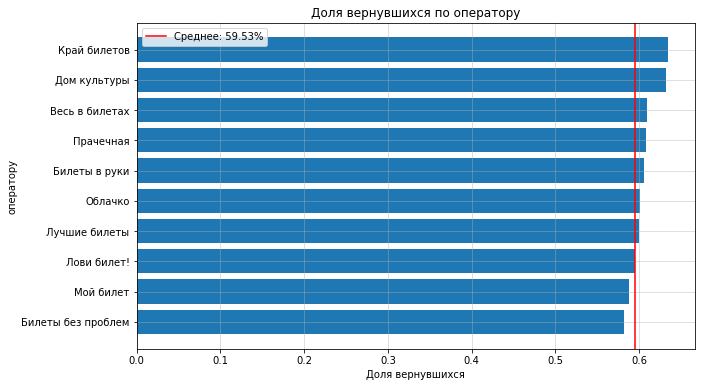


Анализ по оператору
                    total_users  returned_users  return_rate
first_service                                               
Край билетов                443           281.0     0.634312
Дом культуры                337           213.0     0.632047
Весь в билетах             1225           746.0     0.608980
Прачечная                   553           336.0     0.607595
Билеты в руки              2398          1453.0     0.605922
Облачко                    2127          1277.0     0.600376
Лучшие билеты              1122           673.0     0.599822
Лови билет!                2684          1598.0     0.595380
Мой билет                  2859          1680.0     0.587618
Билеты без проблем         4710          2740.0     0.581741


In [59]:
# Строим графики для каждого сегмента
plot_simple_segment(device_stats, 'типу устройства')
print()
print("Анализ по типу устройства")
device_stats_head = device_stats.sort_values('total_users', ascending=False).head(10)
device_stats_head = device_stats_head.sort_values('return_rate', ascending=False)
print(device_stats_head)

plot_simple_segment(region_stats, 'региону') 

print()
print("Анализ по регионам")
region_stats_head = region_stats.sort_values('total_users', ascending=False).head(10)
region_stats_head = region_stats_head.sort_values('return_rate', ascending=False)
print(region_stats_head)

plot_simple_segment(event_stats, 'типу мероприятия')
print()
print("Анализ по типу мероприятия")
event_stats_head = event_stats.sort_values('total_users', ascending=False).head(10)
event_stats_head = event_stats_head.sort_values('return_rate', ascending=False)
print(event_stats_head)

plot_simple_segment(service_stats, 'оператору')
print()
print("Анализ по оператору")
service_stats_head = service_stats.sort_values('total_users', ascending=False).head(10)
service_stats_head = service_stats_head.sort_values('return_rate', ascending=False)
print(service_stats_head)

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ лояльности пользовательских сегментов

**Основные «точки входа» в сервис:**
* **Операторы:** преобладание «Билеты без проблем»
* **Устройства:** доминирование мобильных устройств
* **Мероприятия:** лидируют концерты
* **География:** лидирует Каменевский регион

**Сегменты с повышенной лояльностью:**
* **По устройствам:**
  * Desktop-пользователи: **61.8%** повторных заказов
  * Mobile-пользователи: **59.1%** повторных заказов

* **По типам мероприятий:**
  * Посетители выставок: **63.0%** повторных заказов
  * Любители театра: **61.9%** повторных заказов

* **По регионам:**
  * Шанырский регион: **66.6%** повторных заказов

* **По операторам:**
  * «Край билетов»: **63.4%** повторных заказов
  * «Дом культуры»: **63.2%** повторных заказов

### Рекомендации по работе с аудиторией:
* Усилить работу с **desktop-пользователями**
* Активнее продвигать **выставки** и **театральные постановки**
* Изучить успешные практики работы в **Шанырском регионе**
* Адаптировать опыт операторов **«Край билетов»** и **«Дом культуры»** для других сегментов

####  ✅✍️Задача 4.1.3. 
Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:
- Гипотеза 1. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- Гипотеза 2. В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ гипотез о поведении пользователей

**Гипотеза 1: влияние типа мероприятия на возврат**
* **Частичное подтверждение:** тип мероприятия влияет на вероятность возврата, но только для определенных категорий
* **Концертная аудитория:** **60%** возврата (**5519** пользователей)
* **Спортивная аудитория:** более низкий показатель — **53%** возврата (**388** пользователей)

**Гипотеза 2: взаимосвязь географии и возврата**
* **Опровержение теории:** выявлена обратная зависимость между количеством пользователей и процентом возврата
* **Регионы с высоким процентом возврата:**
  * Шанырский регион
  * Светополянский округ
* **Регионы с большим количеством пользователей:**
  * Североярская область
  * Каменевский регион (процент возврата ниже на **4-6%**)
* **Важный факт:** несмотря на более низкий процент возврата, абсолютное количество вернувшихся пользователей в крупных регионах в **10 раз** превышает показатели небольших территорий

**Общий вывод:** географическое расположение и тип первого заказа влияют на поведение пользователей, но не всегда коррелируют с общими показателями возврата аудитории.

### Задача 4.2. 
Исследование поведения пользователей через показатели выручки и состава заказа
- Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.
- Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

####  Задача 4.2.1. 
Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

Постройте сравнительные гистограммы распределения средней выручки с билета ( avg_revenue_rub ):
- для пользователей, совершивших один заказ;
- для вернувшихся пользователей, совершивших 2 и более заказа.

Ответьте на вопросы: 
- В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
- Есть ли различия между группами?

`Рекомендации:`
- Используйте одинаковые интервалы ( bins ) и прозрачность ( alpha ), чтобы визуально сопоставить распределения.
- Задайте параметру density значение True, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

In [60]:
df_profile_filtred.columns

Index(['user_id', 'first_order_dt', 'last_order_dt', 'first_device',
       'first_region', 'first_service', 'first_event_type', 'count_order',
       'mean_revenue', 'mean_tickets', 'mean_days', 'is_two', 'is_five'],
      dtype='object')

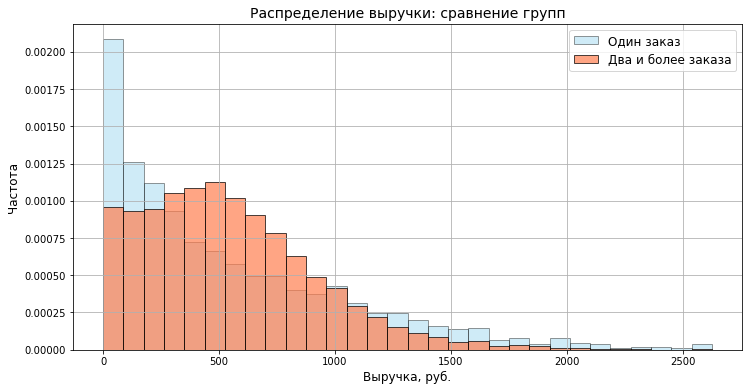

In [61]:
# Фильтрация данных
data_filtered_two_true = df_profile_filtred[df_profile_filtred['is_two'] == 1] 
data_filtered_two_false = df_profile_filtred[df_profile_filtred['is_two'] == 0]

# Создаем фигуру
plt.figure(figsize=(12, 6))

# Гистограмма 1: Только is_two == 0
plt.hist(
    data_filtered_two_false['mean_revenue'], 
    bins=30, 
    edgecolor='black', 
    alpha=0.4,  # Прозрачность для наложения
    color='skyblue',
    label='Один заказ',
    density=True
)

# Гистограмма 2: Только is_two == 1
plt.hist(
    data_filtered_two_true['mean_revenue'], 
    bins=30,  # Лучше использовать те же bins для сравнения
    edgecolor='black', 
    alpha=0.7,  # Меньше прозрачности, чтобы была видима
    color='coral',
    label='Два и более заказа',
    density=True
)

# Настройка графика
plt.title('Распределение выручки: сравнение групп', fontsize=14)
plt.xlabel('Выручка, руб.', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=1)
plt.show()

#### Промежуточный вывод

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ распределения выручки по количеству заказов

**Распределение по группам пользователей:**

* **Пользователи с одним заказом:**
  * Основной диапазон: **0–500 рублей**
  * Пик концентрации: **150–250 рублей** (вероятность **0.00175**)
  * Характерный признак: длинный хвост до **2500 рублей**

* **Пользователи с двумя и более заказами:**
  * Основной диапазон: **0–500 рублей**
  * Пик концентрации: **100–200 рублей** (вероятность **0.002**)
  * Более выраженная концентрация в нижнем диапазоне

**Ключевые различия:**

* **Структура распределения:**
  * У повторных покупателей выше пик распределения
  * У однократных пользователей шире разброс сумм

* **Особенности поведения:**
  * Повторные клиенты делают более мелкие заказы
  * Одноразовые пользователи совершают редкие, но крупные покупки

**Выводы:**

* Сервис эффективнее удерживает клиентов, совершающих небольшие регулярные заказы
* Пользователи с высокой средней суммой заказа менее склонны к повторным покупкам
* Распределение выручки у постоянных клиентов более компактное и предсказуемое
* Одноразовые покупатели демонстрируют более вариативное поведение с редкими крупными транзакциями

####  Задача 4.2.2. 
Сравните распределение по средней выручке с заказа в двух группах пользователей:
- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

- Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

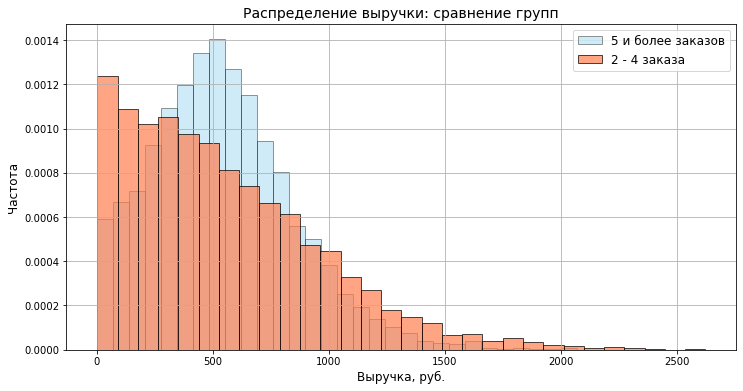

In [62]:
# Фильтрация данных
data_filtered_two_true = df_profile_filtred[df_profile_filtred['is_two'] == 1] 
data_filtered_five_true = df_profile_filtred[df_profile_filtred['is_five'] == 1]

# Объединяем датафреймы и оставляем только уникальные строки из data_filtered_two_true (оставляем только пользователей с заказами 2-4)
result = data_filtered_two_true.merge(data_filtered_five_true, how='left', indicator=True)
result = result[result['_merge'] == 'left_only'].drop('_merge', axis=1)

# Создаем фигуру
plt.figure(figsize=(12, 6))

# Гистограмма 1: Только is_five == 1
plt.hist(
    data_filtered_five_true['mean_revenue'], 
    bins=30, 
    edgecolor='black', 
    alpha=0.4,  # Прозрачность для наложения
    color='skyblue',
    label='5 и более заказов',
    density=True
)

# Гистограмма 2: Только is_two == 1, без is_five == 1
plt.hist(
    result['mean_revenue'], 
    bins=30,  # Лучше использовать те же bins для сравнения
    edgecolor='black', 
    alpha=0.7,  # Меньше прозрачности, чтобы была видима
    color='coral',
    label='2 - 4 заказа',
    density=True
)

# Настройка графика
plt.title('Распределение выручки: сравнение групп', fontsize=14)
plt.xlabel('Выручка, руб.', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=1)
plt.show()

#### Промежуточный вывод

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ поведения пользователей по количеству заказов

**Сегмент с высокой лояльностью (5+ заказов):**
* **Низкая средняя выручка** на один заказ
* **Высокая концентрация** в нижнем ценовом сегменте
* **Стабильное поведение** при совершении покупок

**Сегмент со средней лояльностью (2–4 заказа):**
* **Более широкий диапазон** сумм заказов
* **Повышенная вариативность** в размере транзакций
* **Возможность совершения** крупных покупок

**Ключевые наблюдения:**
* Чем выше количество заказов, тем ниже средняя стоимость одного заказа
* Наиболее лояльные пользователи демонстрируют более предсказуемое поведение в ценовом диапазоне
* Пользователи со средним уровнем лояльности показывают большую гибкость в выборе стоимости мероприятий

#### ✅Задача 4.2.3. 
Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

Изучите распределение пользователей по среднему количеству билетов в заказе ( avg_tickets_count ) и опишите основные 
наблюдения.

Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
- от 1 до 2 билетов;
- от 2 до 3 билетов;
- от 3 до 5 билетов;
- от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.

Ответьте на вопросы:
- Как распределены пользователи по сегментам — равномерно или сконцентрировано?
- Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

In [63]:
df_segments = df_profile_filtred.copy()

In [64]:
# Добавляем сегментацию по количеству билетов
def assign_segment(count):
    if count < 2:
        return 'от 1 до 2 билетов'
    elif count < 3:
        return 'от 2 до 3 билетов'
    elif count < 5:
        return 'от 3 до 5 билетов'
    elif count >= 5:
        return 'от 5 и более билетов'
    else:
        return 'Ошибка'

df_segments['segments'] = df_segments['mean_tickets'].apply(assign_segment)

In [65]:
df_segments

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,count_order,mean_revenue,mean_tickets,mean_days,is_two,is_five,segments
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1522.0,4.0,NaN,0,0,от 3 до 5 билетов
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.0,3.0,75.0,1,0,от 3 до 5 билетов
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.0,3.0,51.0,1,0,от 3 до 5 билетов
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,918.0,4.0,NaN,0,0,от 3 до 5 билетов
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.0,2.0,16.0,1,0,от 2 до 3 билетов
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21545,ffed3ff067d4f12,2024-07-31,2024-10-17,mobile,Малиновая область,Лучшие билеты,другое,4,51.0,2.0,26.0,1,0,от 2 до 3 билетов
21546,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,9,688.0,3.0,13.0,1,1,от 3 до 5 билетов
21547,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,2,851.0,2.0,74.0,1,0,от 2 до 3 билетов
21549,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,1,662.0,2.0,NaN,0,0,от 2 до 3 билетов


In [66]:
def show_users_stats_bin(tmp0, column1, column2):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    users_stats_bin = pd.DataFrame({
        'Кол-во пользователей': tmp0.groupby(column1)[column2].count(),
        'Доля пользователей совершивших повторные заказы': tmp0.groupby(column1)[column2].sum().astype('float') / tmp0[column1].count()
    })
   
    
    #Сортировка по количеству пользователей
    users_stats_bin = users_stats_bin.sort_values('Кол-во пользователей', ascending=False)
    
    # Форматируем при выводе через Styler
    return (users_stats_bin.style.format({'Доля пользователей совершивших повторные заказы': '{:.3f}'}).background_gradient(cmap='coolwarm'))

In [67]:
show_users_stats_bin(df_segments, 'segments', 'is_two')

,Кол-во пользователей,Доля пользователей совершивших повторные заказы
segments,,
от 3 до 5 билетов,10870,0.328
от 2 до 3 билетов,7632,0.250
от 1 до 2 билетов,1462,0.014
от 5 и более билетов,496,0.003


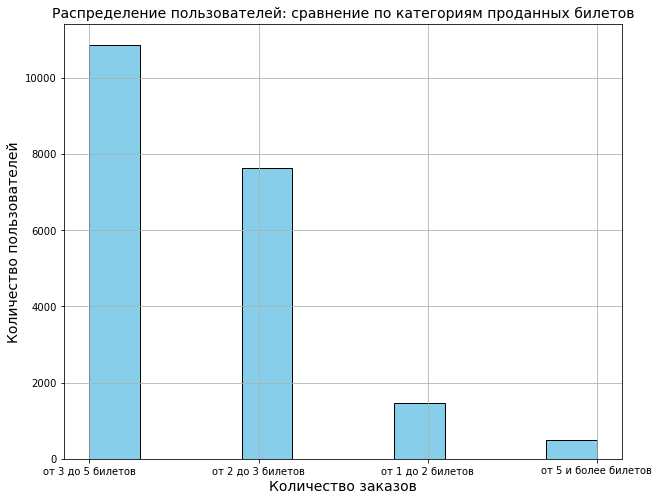

In [68]:
# Для наглядности добавляем гистаграмму
# Создаем фигуру
plt.figure(figsize=(10, 8))

# Гистограмма
plt.hist(
    df_segments['segments'], 
    bins=10,
    edgecolor='black', 
    color='skyblue'
)

# Настройка графика
plt.title('Распределение пользователей: сравнение по категориям проданных билетов', fontsize=14)
plt.xlabel('Количество заказов', fontsize=14)
plt.ylabel('Количество пользователей', fontsize=14)
plt.grid()
plt.show()

               segments  total_users  returned_users  return_rate
0     от 2 до 3 билетов         7632          5113.0     0.669942
1     от 3 до 5 билетов        10870          6707.0     0.617019
2     от 1 до 2 билетов         1462           289.0     0.197674
3  от 5 и более билетов          496            71.0     0.143145


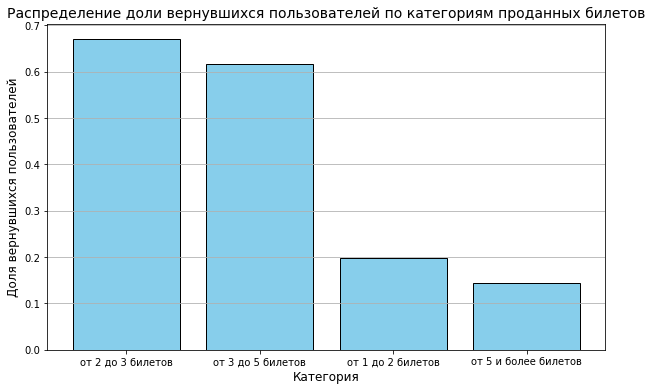

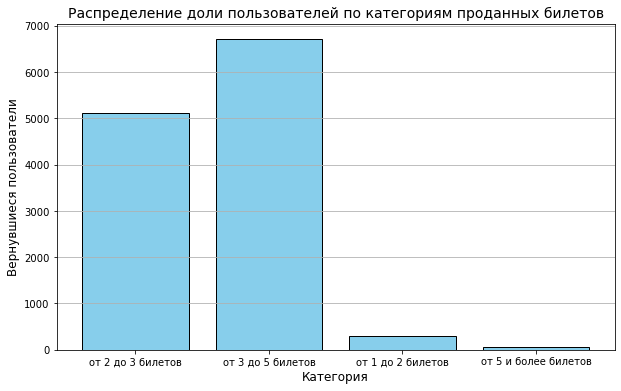

In [69]:
def analyze_segment(df, segment_column, returned_column):

    # Анализ возвращаемости по сегменту

    # Группируем по сегменту
    result = df.groupby(segment_column).agg(
        total_users=(returned_column, 'count'),  # всего пользователей в сегменте
        returned_users=(returned_column, 'sum')  # вернувшихся
    )
    
    # Считаем долю вернувшихся ВНУТРИ каждого сегмента
    result['return_rate'] = result['returned_users'] / result['total_users']
    
    # Сортируем по доле возврата (от большей к меньшей)
    result = result.sort_values('return_rate', ascending=False)

    return result
df_for_plt = analyze_segment(df_segments, 'segments', 'is_two')
df_for_plt = df_for_plt.reset_index()
#df_for_plt = df_for_plt.sort_values('segments', ascending=False).reset_index()
print(df_for_plt)

# Для наглядности добавляем гистаграмму
# Создаем фигуру
plt.figure(figsize=(10, 6))


plt.bar(
    df_for_plt['segments'],
    df_for_plt['return_rate'],
    color='skyblue',
    edgecolor='black'
)

# Настройка графика
plt.title('Распределение доли вернувшихся пользователей по категориям проданных билетов', fontsize=14)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Доля вернувшихся пользователей', fontsize=12)
plt.xticks()  # Наклон подписей для читаемости
plt.grid(axis='y', alpha=1)
plt.show()

# Создаем фигуру
plt.figure(figsize=(10, 6))


plt.bar(
    df_for_plt['segments'],
    df_for_plt['returned_users'],
    color='skyblue',
    edgecolor='black'
)

# Настройка графика
plt.title('Распределение доли пользователей по категориям проданных билетов', fontsize=14)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Вернувшиеся пользователи', fontsize=12)
plt.xticks()  # Наклон подписей для читаемости
plt.grid(axis='y', alpha=1)
plt.show()

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ лояльности по количеству билетов

**Распределение пользователей по сегментам:**
* **Основной сегмент:** 2–3 и 3–5 билетов (**~12 000** пользователей)
* **Меньшие сегменты:** 1–2 и 5+ билетов

**Показатели возврата по сегментам:**
* **1–2 билета:** крайне низкий возврат (**19%**)
* **5+ билетов:** минимальный возврат (**14%**)
* **2–3 билета:** максимальная лояльность (**67%**)
* **3–5 билетов:** высокий уровень возврата (**62%**)

**Ключевые выводы:**
* Наибольшую лояльность демонстрируют пользователи, приобретающие **2–5 билетов** за заказ
* Пик повторных покупок приходится на сегмент **3–5 билетов**
* Сегменты с экстремальными значениями (мало или много билетов) показывают низкую склонность к повторным заказам
* Основная масса лояльных пользователей концентрируется в среднем диапазоне количества билетов

### Задача 4.3. 
Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:
- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

#### ✅Задача 4.3.1. 
Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.
- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.

- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

In [70]:
df_segments_week = df_profile_filtred.copy()

In [71]:
df_segments_week['weekday'] = df_segments_week['first_order_dt'].dt.day_name()

In [72]:
analyze_segment(df_segments_week, 'weekday', 'is_two')

,total_users,returned_users,return_rate
weekday,,,
Wednesday,2939,1792.0,0.609731
Monday,2771,1683.0,0.607362
Saturday,3076,1857.0,0.603706
Tuesday,2977,1778.0,0.597246
Friday,3112,1820.0,0.584833
Thursday,2996,1747.0,0.583111
Sunday,2589,1503.0,0.580533


     weekday  total_users  returned_users  return_rate
0  Wednesday         2939          1792.0     0.609731
1     Monday         2771          1683.0     0.607362
2   Saturday         3076          1857.0     0.603706
3    Tuesday         2977          1778.0     0.597246
4     Friday         3112          1820.0     0.584833
5   Thursday         2996          1747.0     0.583111
6     Sunday         2589          1503.0     0.580533


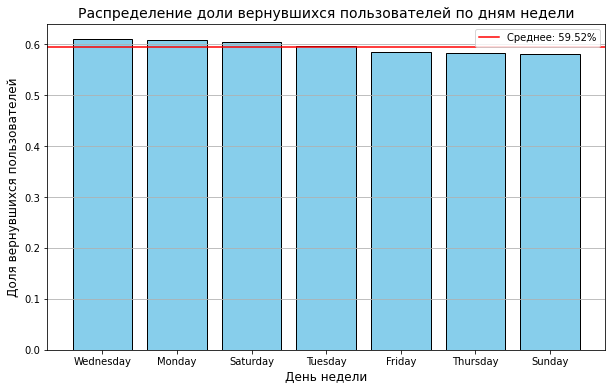

In [73]:
df_for_week_plt = analyze_segment(df_segments_week, 'weekday', 'is_two')
df_for_week_plt = df_for_week_plt.reset_index()

print(df_for_week_plt)

# Для наглядности добавляем гистаграмму
# Создаем фигуру
plt.figure(figsize=(10, 6))


plt.bar(
    df_for_week_plt['weekday'],
    df_for_week_plt['return_rate'],
    color='skyblue',
    edgecolor='black'
)

    # Добавляем среднее значение
avg_returne = df_for_week_plt['return_rate'].mean()
plt.axhline(y=avg_returne, color='red', linestyle='-', 
                label=f'Среднее: {avg_returne:.2%}')

# Настройка графика
plt.title('Распределение доли вернувшихся пользователей по дням недели', fontsize=14)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Доля вернувшихся пользователей', fontsize=12)
plt.xticks()  # Наклон подписей для читаемости
plt.grid(axis='y', alpha=1)
plt.legend()
plt.show()

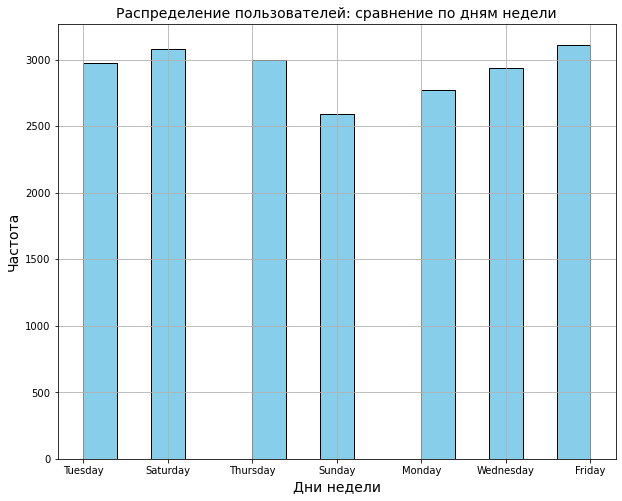

In [74]:
# Для наглядности добавляем гистаграмму
# Создаем фигуру
plt.figure(figsize=(10, 8))

# Гистограмма 
plt.hist(
    df_segments_week['weekday'], 
    bins=15,
    edgecolor='black', 
    color='skyblue'
)

# Настройка графика
plt.title('Распределение пользователей: сравнение по дням недели', fontsize=14)
plt.xlabel('Дни недели', fontsize=14)
plt.ylabel('Частота', fontsize=14)
plt.grid()
plt.show()

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ влияния дня недели на возвращаемость пользователей

**Основные наблюдения:**
* **Общее распределение:** количество пользователей по дням недели распределено равномерно
* **Диапазон возвращаемости:** колебания в пределах **58–61%**

**Динамика по дням недели:**
* **Высокая возвращаемость:** среда, пятница, воскресенье
* **Низкая возвращаемость:** воскресенье (минимальный показатель)
* **Разница между днями:** не превышает **3%**

**Интерпретация результатов:**
* Влияние дня недели на возвращаемость пользователей **незначительно**
* Наблюдаются небольшие различия в поведении пользователей

**Возможные причины:**
* **Рабочие дни:** более осознанный подход к покупкам
* **Суббота:** активный шопинг и планирование мероприятий
* **Пятница и воскресенье:** склонность к спонтанным покупкам

**Рекомендации:**
* Разработать специальные предложения для повышения лояльности в дни с низкой возвращаемостью
* Учитывать особенности покупательского поведения по дням недели при планировании маркетинговых активностей

#### ❌✅Задача 4.3.2.
Изучите, как средний интервал между заказами влияет на удержание клиентов.

Рассчитайте среднее время между заказами для двух групп пользователей:
- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

In [75]:
df_profile_filtred

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,count_order,mean_revenue,mean_tickets,mean_days,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1522.0,4.0,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.0,3.0,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.0,3.0,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,918.0,4.0,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.0,2.0,16.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21545,ffed3ff067d4f12,2024-07-31,2024-10-17,mobile,Малиновая область,Лучшие билеты,другое,4,51.0,2.0,26.0,1,0
21546,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,9,688.0,3.0,13.0,1,1
21547,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,2,851.0,2.0,74.0,1,0
21549,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,1,662.0,2.0,NaN,0,0


In [76]:
# Добавляем сегментацию по количеству билетов
def two_segment(count):
    if count < 2:
        return '1 билет'
    if (count > 1) & (count < 5):
        return 'от 2 до 4 билетов'
    elif count >= 5:
        return 'от 5 и более билетов'
    else:
        return 'Ошибка'
df_two_segments = df_profile_filtred.copy()
df_two_segments['segments'] = df_profile_filtred['count_order'].apply(two_segment)

In [77]:
mean_for_segments = round(df_two_segments.groupby('segments')['count_order'].mean())

print(f'В группе совершивших 2-4 заказа средний интервал между заказами: {mean_for_segments[1]}')
print(f'В группе совершивших 5 и более заказов средний интервал между заказами: {mean_for_segments[2]}')

В группе совершивших 2-4 заказа средний интервал между заказами: 3.0
В группе совершивших 5 и более заказов средний интервал между заказами: 11.0


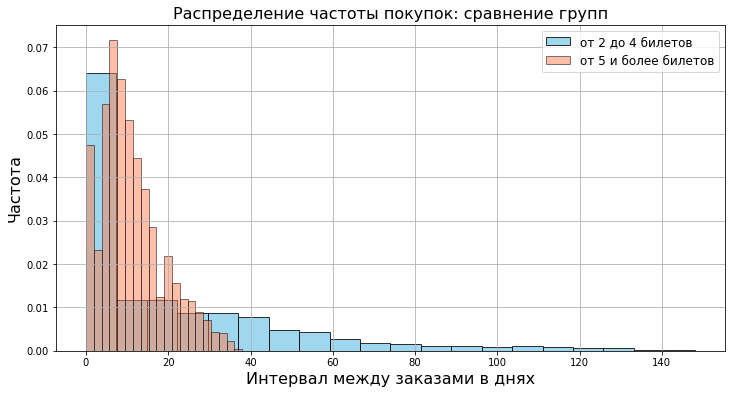

In [78]:
data_filtered_segment_two = df_two_segments[df_two_segments['segments'] == 'от 2 до 4 билетов'] 
data_filtered_segment_five = df_two_segments[df_two_segments['segments'] == 'от 5 и более билетов']

# Создаем фигуру
plt.figure(figsize=(12, 6))

# Гистограмма 1: Только is_five == 1
plt.hist(
    data_filtered_segment_two['mean_days'], 
    bins=20, 
    edgecolor='black', 
    alpha=0.8,  # Прозрачность для наложения
    color='skyblue',
    label='от 2 до 4 билетов',
    density=True
)

# Гистограмма 2: Только is_two == 1, без is_five == 1
plt.hist(
    data_filtered_segment_five['mean_days'], 
    bins=20,  # Лучше использовать те же bins для сравнения
    edgecolor='black', 
    alpha=0.5,  # Меньше прозрачности, чтобы была видима
    color='coral',
    label='от 5 и более билетов',
    density=True
)

# Настройка графика
plt.title('Распределение частоты покупок: сравнение групп', fontsize=16)
plt.xlabel('Интервал между заказами в днях', fontsize=16)
plt.ylabel('Частота', fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=1)
plt.show()

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ частоты повторных покупок

**Ключевое наблюдение:**
* При увеличении интервала между покупками **более 5 дней** вероятность повторных заказов существенно снижается

**Выводы:**
* Существует критическая точка в **5 дней**, после которой вероятность повторной покупки уменьшается
* Временной фактор играет важную роль в поведении пользователей

**Рекомендации:**
* Разработать специальные стратегии вовлечения для:
  * Оперативного возвращения пользователей
  * Стимулирования новых заказов в течение первых 5 дней
* Внедрить механизмы напоминания и мотивации для поддержания активности
* Учитывать временной фактор при планировании маркетинговых кампаний

## Корреляционный анализ количества покупок и признаков пользователя
Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

#### Задача 4.4.1 
Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции phi_k между признаками профиля пользователя и числом заказов ( total_orders ). При необходимости используйте параметр interval_cols для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в total_orders. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю total_orders, а затем повторите корреляционный анализ. 

Выделите такие сегменты:
- 1 заказ;
- от 2 до 4 заказов;
- от 5 и выше.

Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

In [79]:
df_profile_filtred.columns

Index(['user_id', 'first_order_dt', 'last_order_dt', 'first_device',
       'first_region', 'first_service', 'first_event_type', 'count_order',
       'mean_revenue', 'mean_tickets', 'mean_days', 'is_two', 'is_five'],
      dtype='object')

interval columns not set, guessing: ['count_order', 'mean_revenue', 'mean_tickets', 'mean_days']


C:\ProgramData\Anaconda3\lib\site-packages\phik\data_quality.py:55: UserWarning: The number of unique values of variable first_order_dt is very large: 153. Are you sure this is not an interval variable? Analysis for pairs of variables including first_order_dt might be slow.
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\phik\data_quality.py:55: UserWarning: The number of unique values of variable last_order_dt is very large: 153. Are you sure this is not an interval variable? Analysis for pairs of variables including last_order_dt might be slow.
  warnings.warn(


Корреляция количества заказов со всеми остальными параметрами (без самого количества заказов):
mean_days           0.484756
last_order_dt       0.399767
first_order_dt      0.394453
mean_tickets        0.338264
mean_revenue        0.263186
first_device        0.039549
first_service       0.038799
first_event_type    0.038119
first_region        0.000000
Name: count_order, dtype: float64


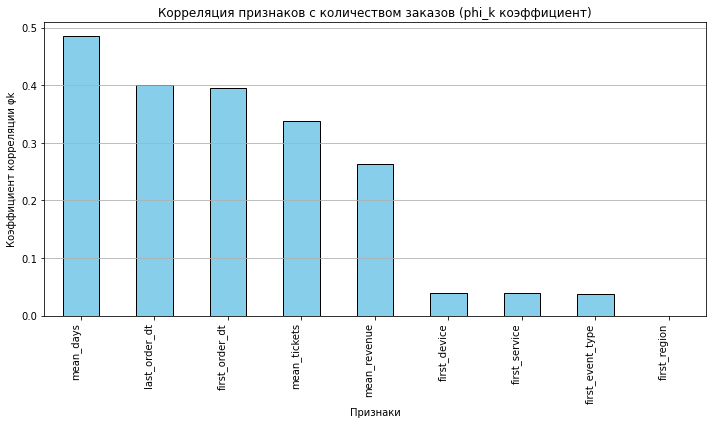

In [80]:
# В список столбцов не включаем столбцы is_two, is_five которые формировались из столбца count_order
correlation_matrix = df_profile_filtred[['first_order_dt', 'last_order_dt', 'first_device',
                                       'first_region', 'first_service', 'first_event_type',
                                       'count_order', 'mean_revenue', 'mean_tickets',
                                       'mean_days']].phik_matrix(interval_cols=None)

# Корреляции с count_order, исключая сам count_order
mean_days_correlations = correlation_matrix['count_order'].drop('count_order').sort_values(ascending=False)

print('Корреляция количества заказов со всеми остальными параметрами (без самого количества заказов):')
print(mean_days_correlations)

# Строим барплот
plt.figure(figsize=(10, 6))
mean_days_correlations.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Корреляция признаков с количеством заказов (phi_k коэффициент)')
plt.ylabel('Коэффициент корреляции φk')
plt.xlabel('Признаки')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='y')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

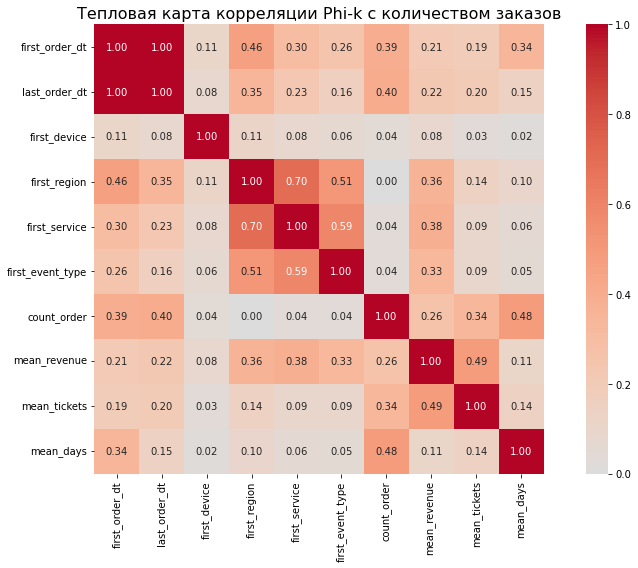

In [81]:
# Создаем тепловую карту с count_order
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, 
            annot=True,     # Показать числа в ячейках
            fmt='.2f',      # Формат чисел: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,       # Центр цветовой шкалы на 0
            square=True)    # Квадратные ячейки

plt.title('Тепловая карта корреляции Phi-k с количеством заказов', fontsize=16)
plt.tight_layout()
plt.show()

In [82]:
df_tree_segments = df_profile_filtred.copy()

In [83]:
# Добавляем сегментацию по количеству билетов
def assign_tree_segment(count):
    if count < 2:
        return '1 заказ'
    elif count <= 4:
        return 'от 2 до 4 билетов'
    elif count >= 5:
        return 'от 5 и более билетов'
    else:
        return 'Ошибка'

df_tree_segments['segments'] = df_tree_segments['count_order'].apply(assign_tree_segment)

In [84]:
df_tree_segments.columns

Index(['user_id', 'first_order_dt', 'last_order_dt', 'first_device',
       'first_region', 'first_service', 'first_event_type', 'count_order',
       'mean_revenue', 'mean_tickets', 'mean_days', 'is_two', 'is_five',
       'segments'],
      dtype='object')

interval columns not set, guessing: ['mean_revenue', 'mean_tickets', 'mean_days']


C:\ProgramData\Anaconda3\lib\site-packages\phik\data_quality.py:55: UserWarning: The number of unique values of variable first_order_dt is very large: 153. Are you sure this is not an interval variable? Analysis for pairs of variables including first_order_dt might be slow.
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\phik\data_quality.py:55: UserWarning: The number of unique values of variable last_order_dt is very large: 153. Are you sure this is not an interval variable? Analysis for pairs of variables including last_order_dt might be slow.
  warnings.warn(


Корреляция количества заказов со всеми остальными параметрами (без самого количества заказов):
mean_days           0.484756
last_order_dt       0.399767
first_order_dt      0.394453
mean_tickets        0.338264
mean_revenue        0.263186
first_device        0.039549
first_service       0.038799
first_event_type    0.038119
first_region        0.000000
Name: count_order, dtype: float64


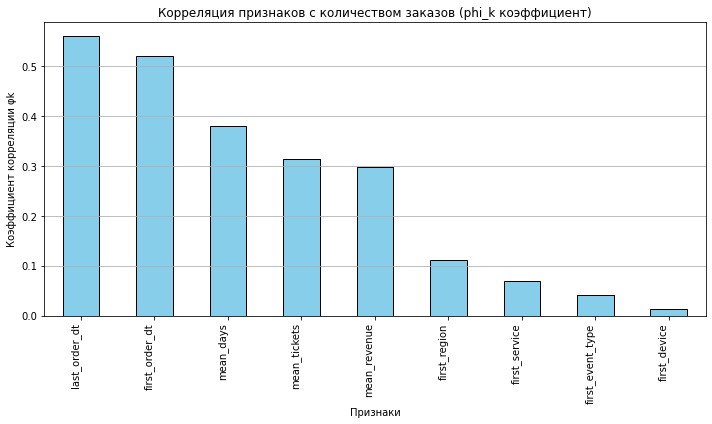

In [85]:
# В список столбцов не включаем столбцы на которых формировался столбец segments и ему подобные count_order, is_two, is_five
correlation_matrix_segments = df_tree_segments[['first_order_dt', 'last_order_dt', 'first_device',
                                       'first_region', 'first_service', 'first_event_type',
                                       'mean_revenue', 'mean_tickets', 'mean_days', 'segments']].phik_matrix(interval_cols=None)

# Корреляции с segments, исключая сам segments
mean_days_correlations_segments = correlation_matrix_segments['segments'].drop('segments').sort_values(ascending=False)

print('Корреляция количества заказов со всеми остальными параметрами (без самого количества заказов):')
print(mean_days_correlations)

# Строим барплот
plt.figure(figsize=(10, 6))
mean_days_correlations_segments.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Корреляция признаков с количеством заказов (phi_k коэффициент)')
plt.ylabel('Коэффициент корреляции φk')
plt.xlabel('Признаки')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='y')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

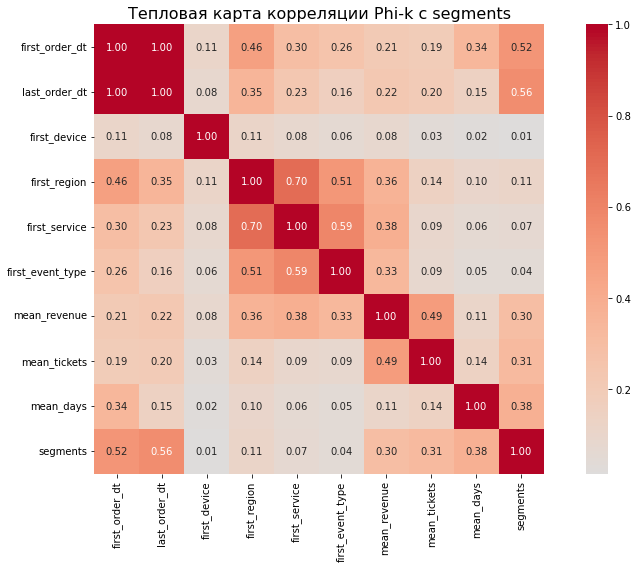

In [86]:
# Создаем тепловую карту с segments
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix_segments, 
            annot=True,     # Показать числа в ячейках
            fmt='.2f',      # Формат чисел: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,       # Центр цветовой шкалы на 0
            square=True)    # Квадратные ячейки

plt.title('Тепловая карта корреляции Phi-k с segments', fontsize=16)
plt.tight_layout()
plt.show()

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Анализ корреляции признаков с количеством заказов

**Сильные корреляционные связи:**
* **Дата последнего заказа** — коэффициент **0.56**
* **Дата первого заказа** — коэффициент **0.52**
* **Средний интервал** между заказами — коэффициент **0.38**

**Умеренные корреляционные связи:**
* **Среднее количество билетов** — коэффициент **0.32**
* **Средняя выручка** — коэффициент **0.30**

**Основные выводы:**
* **Временные признаки** демонстрируют самую сильную связь с количеством заказов
* **Географические и технические параметры** (устройство, регион, сервис) практически не влияют на частоту заказов
* **Сегментация** по количеству заказов помогла обнаружить закономерности, которые не были заметны при анализе общего показателя count_order

**Практические рекомендации:**
* Уделять особое внимание временным характеристикам поведения пользователей
* Не фокусироваться на географических и технических признаках при прогнозировании количества заказов
* Использовать сегментацию для более глубокого анализа пользовательского поведения

## ✍️Общие выводы и рекомендации
В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:
- Информацию о данных, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- Основные результаты анализа. Например, укажите:
- Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
- Какие признаки первого заказа связаны с возвратом пользователей?
- Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
- Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
- Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.
- В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

</font><font color='Blue'><b>Комментарий stud_1</b></font><br>
### Итоговые выводы и рекомендации

**Ключевые инсайты по поведению пользователей:**

* **Лояльные сегменты:**
  * Пользователи, заказывающие **2-5 билетов** за раз (лояльность 25-33%)
  * Клиенты, начавшие с **концертов** (возвращаемость 26.7%)
  * **Desktop-пользователи** (возвращаемость 61.8%)
  * Посетители **выставок** и **театра** (63.0% и 61.9% соответственно)

* **Критические факторы удержания:**
  * Временной интервал между заказами (**до 5 дней**)
  * Количество билетов в заказе
  * Тип первого мероприятия
  * Канал входа

**Выявленные проблемы:**

* **Низкие показатели возврата:**
  * Пользователи с **1-2 билетами** (1.4%)
  * Клиенты **спортивных мероприятий** (2%)
  * Заказы с **5+ билетами** (0.3%)
  * Покупки в **воскресенье**

**Временные паттерны:**
* **Критический период** — первые 5 дней после покупки
* **Оптимальный интервал** между заказами — около 11 дней
* **Максимальный интервал** без потери лояльности — до 20 дней

### Рекомендации по улучшению удержания

**Стратегия работы с сегментами:**
* **Приоритетная группа:** пользователи 2-5 билетов — персонализированные предложения и программы лояльности
* **Работа со слабыми сегментами:** специальные акции для клиентов с 1-2 билетами
* **Географический фокус:** усиление присутствия в Каменевском регионе

**Временные триггеры:**
* Система напоминаний при превышении 5-дневного интервала
* Специальные предложения через 7-10 дней после первой покупки в "слабые" дни
* Push-уведомления для мобильных пользователей

**Продуктовые улучшения:**
* Оптимизация процесса повторного заказа
* Сохранение истории покупок
* Персонализированные рекомендации по мероприятиям

**Мониторинг эффективности:**
* Отслеживание возвращаемости по ключевым сегментам
* Анализ эффективности внедряемых мер
* Корректировка стратегии на основе полученных данных

**Технические рекомендации:**
* Внедрение системы скоринга пользователей
* Разработка триггерных email-рассылок
* Создание программы лояльности с учетом поведенческих паттернов